In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             159 non-null    object 
 1   age              170 non-null    int64  
 2   phone_number     116 non-null    float64
 3   sex              155 non-null    object 
 4   branch           155 non-null    object 
 5   salary           170 non-null    float64
 6   bonus            146 non-null    float64
 7   random_column    152 non-null    float64
 8   date_of_joining  170 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 12.1+ KB


In [23]:
df[df['name'].isnull()]

KeyError: 'name'

In [ ]:
df=df.drop('name',axis=1)

In [ ]:
df.info()

In [25]:
df['phone_number']=df['phone_number'].astype(str)


In [27]:
df.drop('phone_number',axis=1,inplace=True)
# df=df.drop('phone_number',axis=1)

In [30]:
df.sex.value_counts()

sex
Male      80
Female    75
Name: count, dtype: int64

In [34]:
df.sex.mode()[0]
df.sex.fillna(df.sex.mode()[0],inplace=True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              170 non-null    int64  
 1   sex              170 non-null    object 
 2   branch           155 non-null    object 
 3   salary           170 non-null    float64
 4   bonus            146 non-null    float64
 5   random_column    152 non-null    float64
 6   date_of_joining  170 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 9.4+ KB


In [40]:
df['branch'].fillna(df.branch.mode()[0],inplace=True)

In [41]:
df

,age,sex,branch,salary,bonus,random_column,date_of_joining
0,28,Male,Engineering,58234.56,38234.12,2.34,2020-03-15
1,35,Female,Sales,65432.10,42156.89,15.67,2018-06-22
2,42,Male,Marketing,71234.45,35678.23,NaN,2019-11-08
3,31,Male,HR,55678.90,40123.45,8.92,2021-01-30
4,29,Female,Finance,62345.67,NaN,5.43,2020-09-12
...,...,...,...,...,...,...,...
165,43,Male,Sales,72678.90,42567.90,19.90,2019-09-30
166,36,Female,Marketing,65890.12,NaN,12.67,2020-07-23
167,44,Male,Finance,74456.78,43234.78,21.34,2018-10-16
168,31,Female,HR,60234.56,37890.45,7.78,2021-05-09


In [42]:
import matplotlib.pyplot as plt


(array([ 7., 12., 19., 21., 25., 11., 13., 20., 24., 18.]),
 array([52345.67 , 55034.559, 57723.448, 60412.337, 63101.226, 65790.115,
        68479.004, 71167.893, 73856.782, 76545.671, 79234.56 ]),
 <BarContainer object of 10 artists>)

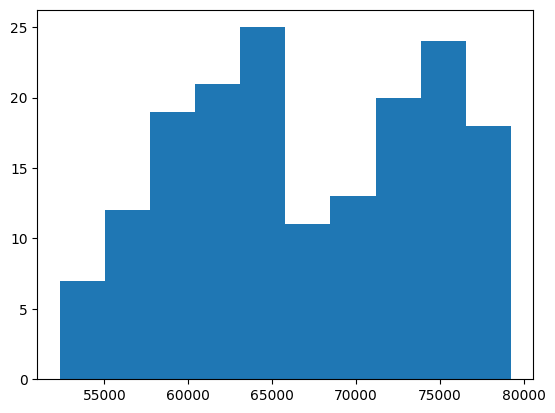

In [43]:
plt.hist(df.salary)

In [45]:
df.salary.fillna(df.salary.median(),inplace=True)

C:\Users\krivi\AppData\Local\Temp\ipykernel_30436\3508794674.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.salary.fillna(df.salary.mean(),inplace=True)


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              170 non-null    int64  
 1   sex              170 non-null    object 
 2   branch           170 non-null    object 
 3   salary           170 non-null    float64
 4   bonus            146 non-null    float64
 5   random_column    152 non-null    float64
 6   date_of_joining  170 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 9.4+ KB


In [73]:
df=pd.read_csv('outlier_data.csv')

In [74]:
df.salary

0     58234.56
1     65432.10
2     71234.45
3     55678.90
4     78901.23
        ...   
93    70234.56
94    64890.23
95    77890.12
96    56678.90
97     2000.00
Name: salary, Length: 98, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1eb8737d750>,
 'caps': [<matplotlib.lines.Line2D at 0x1eb8736ca10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eb87380a10>],
 'medians': [<matplotlib.lines.Line2D at 0x1eb87375f10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eb87374b10>],
 'means': []}

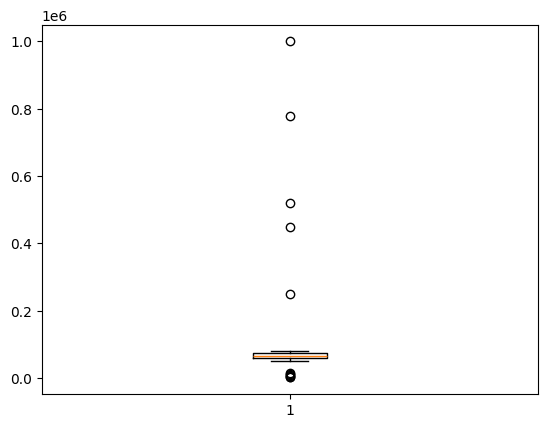

In [75]:
plt.boxplot(df.salary)

In [76]:
df.salary.describe()

count        98.000000
mean      90128.217755
std      133850.244854
min        2000.000000
25%       59879.935000
50%       65555.500000
75%       73623.370000
max      999999.990000
Name: salary, dtype: float64

In [77]:
# IQR
qr1=df.salary.quantile(0.25)
qr3=df.salary.quantile(0.75)
iqr=qr3-qr1


In [78]:
# qr1-1.5*iqr<x<qr3+iqr*1.5 
lower_boundary=qr1-iqr*1.5

In [79]:
lower_boundary

np.float64(39264.7825)

In [80]:
upper_boundary=qr3+iqr*1.5

In [81]:
upper_boundary

np.float64(94238.52249999999)

In [86]:
outler=(df.salary < lower_boundary) | (df.salary > upper_boundary)
df[outler]

,name,age,phone_number,sex,branch,salary,bonus,random_column,date_of_joining
7,James Taylor,40,9789012345,Male,Legal,250000.00,43567.89,18.45,2018-12-09
15,Joseph Garcia,3,9567890432,Male,IT,15000.00,42345.67,11.23,2019-01-16
23,Steven King,108,9345679210,Male,Legal,450000.00,44567.89,189.23,2016-12-03
34,Carol Turner,29,9456781321,Female,Marketing,8500.00,37678.90,7.89,2021-02-24
37,Kevin Parker,1,9789014654,Male,Legal,12000.00,42456.89,16.89,2018-12-29
50,Melissa Bell,134,9012348987,Female,Finance,520000.00,99999.99,256.78,2020-04-19
62,Kathleen Ramirez,-5,9234562109,Female,IT,5000.00,36345.89,4.89,2021-09-29
71,Albert Bennett,150,9123452098,Male,IT,780000.00,98765.43,312.45,2017-09-08
80,Martha Long,0,9012341987,Female,Engineering,3500.00,1200.00,0.12,2020-02-27
91,Patrick Alexander,200,9123454098,Male,Finance,999999.99,150000.00,456.78,2017-08-16


In [88]:
df=df[~outler]

In [89]:
df.salary.describe()
count        98.000000
mean      90128.217755
std      133850.244854
min        2000.000000
25%       59879.935000
50%       65555.500000
75%       73623.370000
max      999999.990000

count       87.000000
mean     66512.245402
std       7427.618405
min      52345.670000
25%      60456.730000
50%      65678.900000
75%      73062.340000
max      79234.560000
Name: salary, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1eb8777ba50>,
 'caps': [<matplotlib.lines.Line2D at 0x1eb87775650>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eb8777ab50>],
 'medians': [<matplotlib.lines.Line2D at 0x1eb8778b990>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eb87790890>],
 'means': []}

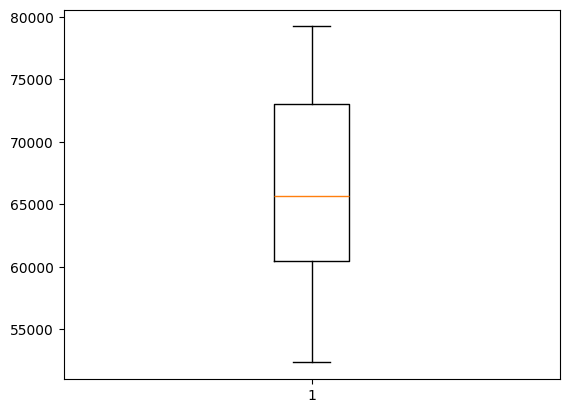

In [90]:
plt.boxplot(df.salary)

In [91]:
count        98.000000
mean      90128.217755
std      133850.244854
min        2000.000000
25%       59879.935000
50%       65555.500000
75%       73623.370000
max      999999.990000

SyntaxError: invalid syntax (2528198864.py, line 1)

In [ ]:
#using zscore
mean=

{'whiskers': [<matplotlib.lines.Line2D at 0x1eb87819590>,
 'caps': [<matplotlib.lines.Line2D at 0x1eb8781b5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eb87818990>],
 'medians': [<matplotlib.lines.Line2D at 0x1eb87820fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eb87821cd0>],
 'means': []}

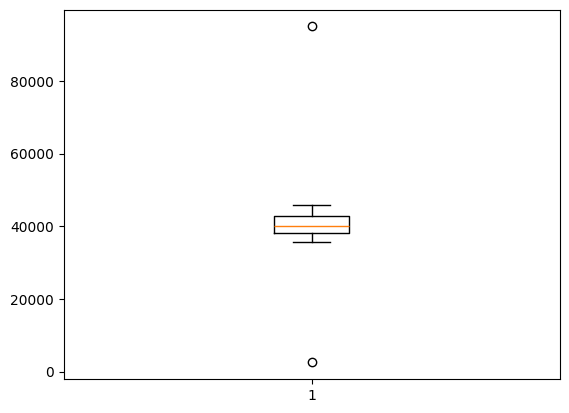

In [95]:
plt.boxplot(df.bonus)

In [111]:
mean=df.bonus.mean()
std=df.bonus.std()
z=(df.bonus-mean)/std
z=abs(z)
df[~(z>3)]

,name,age,phone_number,sex,branch,salary,bonus,random_column,date_of_joining
0,John Smith,28,9876543210,Male,Engineering,58234.56,38234.12,2.34,2020-03-15
1,Sarah Johnson,35,9123456789,Female,Sales,65432.10,42156.89,15.67,2018-06-22
2,Michael Brown,31,9234567890,Male,Marketing,71234.45,35678.23,8.92,2019-11-08
3,Emily Davis,29,9345678901,Female,HR,55678.90,40123.45,5.43,2020-09-12
4,Robert Wilson,95,9456789012,Male,Engineering,78901.23,45678.90,25.78,2017-04-18
...,...,...,...,...,...,...,...,...,...
92,Diane Russell,29,9234565109,Female,HR,57890.12,36890.56,5.67,2021-10-08
93,Lawrence Griffin,41,9345676210,Male,Operations,70234.56,41890.34,17.23,2019-03-01
94,Pamela Diaz,35,9456787321,Female,IT,64890.23,39567.89,12.34,2020-07-24
95,Henry Hayes,47,9567898432,Male,IT,77890.12,44901.67,26.78,2017-05-17


In [97]:
mean,std

(np.float64(40665.70206896552), np.float64(7713.879617658563))

{'whiskers': [<matplotlib.lines.Line2D at 0x1eb89aea250>,
 'caps': [<matplotlib.lines.Line2D at 0x1eb89ae9650>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eb89ad9e10>],
 'medians': [<matplotlib.lines.Line2D at 0x1eb89ba3e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eb89ac95d0>],
 'means': []}

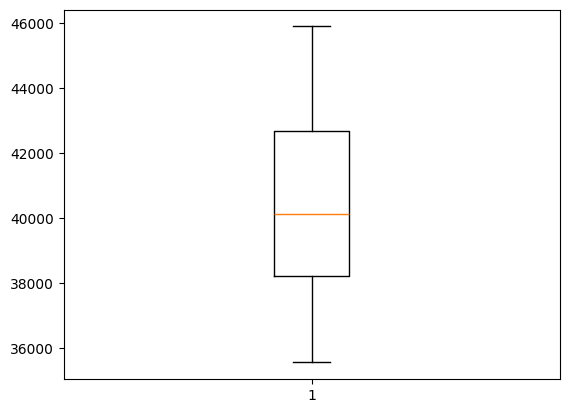

In [112]:
plt.boxplot(df[~(z>3)]['bonus'])